In [17]:
import os
import pandas as pd
from pathlib import Path

base_path = Path.cwd() / "Data"
# Load task data
task_data = pd.read_csv(base_path / "onet_tasks.csv")
task_data.columns = task_data.columns.str.strip()

# Load all ISCO sheets dynamically
isco_data = {
    f"ISCO{i}": pd.read_excel(base_path / "Eurostat_employment_isco.xlsx", sheet_name=f"ISCO{i}")
    for i in range(1, 10)
}

# Select countries
countries = ["Belgium", "Spain", "Poland"]

# Compute totals
totals = {
    country: sum(df[country] for df in isco_data.values())
    for country in countries
}

# Convert to DataFrame
totals_df = pd.DataFrame(totals)
totals_df.head()


# Add ISCO level dynamically + combine
all_data = pd.concat(
    [
        df.assign(ISCO=i)
        for i, df in enumerate(isco_data.values(), start=1)
    ],
    ignore_index=True
)

# Add totals + shares dynamically
for country in countries:
    all_data[f"total_{country}"] = pd.concat(
        [totals[country]] * len(isco_data),
        ignore_index=True
    )
    all_data[f"share_{country}"] = (
        all_data[country] / all_data[f"total_{country}"]
    )

all_data.head()


# --- Task aggregation + merge + weighted standardisation ---

# 1. Extract 1-digit ISCO
task_data["isco08_1dig"] = task_data["isco08"].astype(str).str[:1].astype(int)

# 2. Aggregate task data
aggdata = (
    task_data
    .groupby("isco08_1dig")
    .mean(numeric_only=True)
    .drop(columns=["isco08"], errors="ignore")
    .reset_index()
)

# 3. Merge with employment data
all_data["ISCO"] = all_data["ISCO"].astype(int)
aggdata["isco08_1dig"] = aggdata["isco08_1dig"].astype(int)

combined = pd.merge(
    all_data,
    aggdata,
    left_on="ISCO",
    right_on="isco08_1dig",
    how="left"
)

# 4. Task variables (corrected names)
task_vars = [
    "t_4A2a4",
    "t_4A2b2",
    "t_4A4a1"
]

# 5. Weighted standardisation function
def weighted_zscore(df, value_col, weight_col):
    mean = (df[value_col] * df[weight_col]).sum() / df[weight_col].sum()
    var = (df[weight_col] * (df[value_col] - mean) ** 2).sum() / df[weight_col].sum()
    std = var ** 0.5
    return (df[value_col] - mean) / std

# 6. Apply per country + per task
for country in countries:
    weight_col = f"share_{country}"
    for task in task_vars:
        combined[f"{task}_z_{country}"] = weighted_zscore(
            combined,
            task,
            weight_col
        )

combined.head()

,TIME,European Union - 28 countries (2013-2020),Belgium,Czechia,Denmark,Spain,Italy,Lithuania,Poland,Finland,...,t_4A3b5_rev,t_4A2a4_z_Belgium,t_4A2b2_z_Belgium,t_4A4a1_z_Belgium,t_4A2a4_z_Spain,t_4A2b2_z_Spain,t_4A4a1_z_Spain,t_4A2a4_z_Poland,t_4A2b2_z_Poland,t_4A4a1_z_Poland
0,2011-Q1,12850.9,279.0,223.5,57.6,879.8,896.0,120.0,963.5,137.2,...,4.270759,1.283003,0.941598,0.931835,1.639543,1.227219,1.238556,1.510081,1.120186,1.148909
1,2011-Q2,12834.2,304.7,226.2,58.2,911.6,897.0,118.9,918.4,135.8,...,4.270759,1.283003,0.941598,0.931835,1.639543,1.227219,1.238556,1.510081,1.120186,1.148909
2,2011-Q3,12763.1,348.8,227.3,107.5,881.4,840.1,107.0,913.8,123.5,...,4.270759,1.283003,0.941598,0.931835,1.639543,1.227219,1.238556,1.510081,1.120186,1.148909
3,2011-Q4,12668.1,347.9,230.3,74.1,888.2,764.9,107.8,935.9,106.6,...,4.270759,1.283003,0.941598,0.931835,1.639543,1.227219,1.238556,1.510081,1.120186,1.148909
4,2012-Q1,12197.3,304.0,231.1,50.6,848.8,762.2,107.5,952.5,102.5,...,4.270759,1.283003,0.941598,0.931835,1.639543,1.227219,1.238556,1.510081,1.120186,1.148909


In [18]:
import numpy as np

# Task variables
task_vars = ["t_4A2a4", "t_4A2b2", "t_4A4a1"]

# Countries and corresponding weight columns
countries = {
    "Belgium": "share_Belgium",
    "Poland": "share_Poland",
    "Spain": "share_Spain"
}

# Loop over countries and tasks
for country, weight_col in countries.items():
    for task in task_vars:
        w = combined[weight_col]
        x = combined[task]
        w_mean = np.average(x, weights=w)
        w_sd = np.sqrt(np.average((x - w_mean)**2, weights=w))
        combined[f"std_{country}_{task}"] = (x - w_mean) / w_sd

# Check result
combined[[f"std_{c}_{t}" for c in countries for t in task_vars]].head()

,std_Belgium_t_4A2a4,std_Belgium_t_4A2b2,std_Belgium_t_4A4a1,std_Poland_t_4A2a4,std_Poland_t_4A2b2,std_Poland_t_4A4a1,std_Spain_t_4A2a4,std_Spain_t_4A2b2,std_Spain_t_4A4a1
0,1.283003,0.941598,0.931835,1.510081,1.120186,1.148909,1.639543,1.227219,1.238556
1,1.283003,0.941598,0.931835,1.510081,1.120186,1.148909,1.639543,1.227219,1.238556
2,1.283003,0.941598,0.931835,1.510081,1.120186,1.148909,1.639543,1.227219,1.238556
3,1.283003,0.941598,0.931835,1.510081,1.120186,1.148909,1.639543,1.227219,1.238556
4,1.283003,0.941598,0.931835,1.510081,1.120186,1.148909,1.639543,1.227219,1.238556


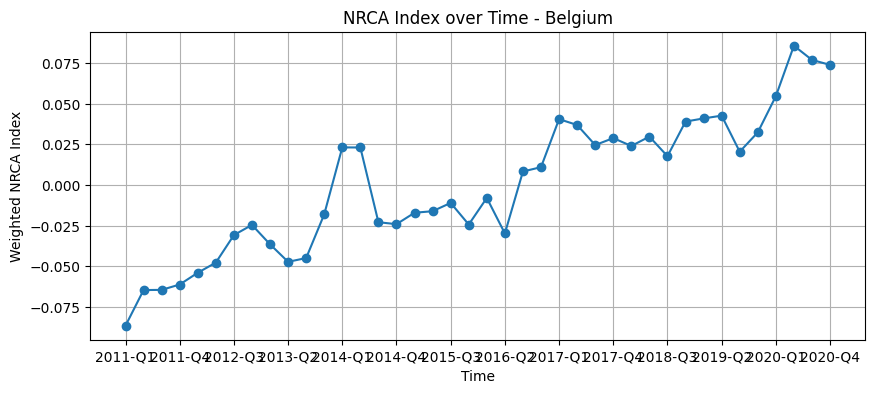

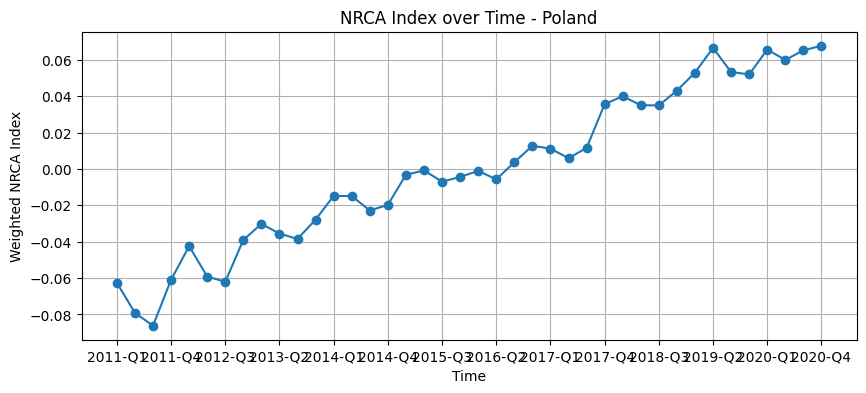

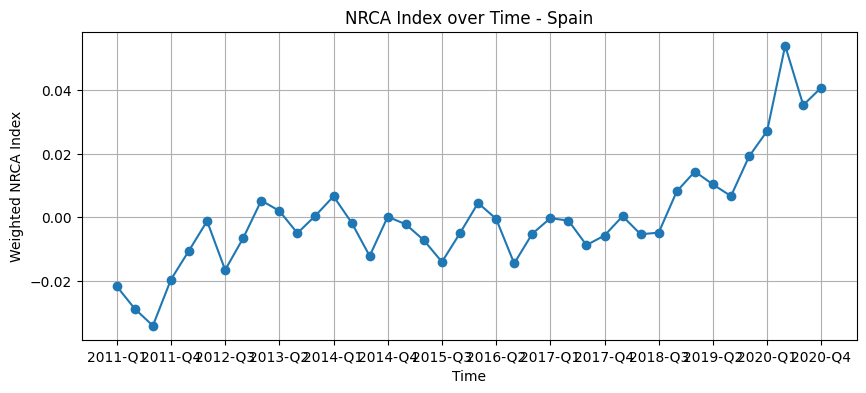

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
countries = {
    "Belgium": "share_Belgium",
    "Poland": "share_Poland",
    "Spain": "share_Spain"
}

# Task variables for NRCA
nrca_tasks = ["t_4A2a4", "t_4A2b2", "t_4A4a1"]

# --- Step 1: compute country-level NRCA sum ---
for country, weight_col in countries.items():
    combined[f"{country}_NRCA"] = combined[[f"std_{country}_{task}" for task in nrca_tasks]].sum(axis=1)

# --- Step 2: weighted standardisation of NRCA ---
for country, weight_col in countries.items():
    x = combined[f"{country}_NRCA"]
    w = combined[weight_col]
    mean = np.average(x, weights=w)
    sd = np.sqrt(np.average((x - mean)**2, weights=w))
    combined[f"std_{country}_NRCA"] = (x - mean) / sd

# --- Step 3: multiply by share to get weighted mean per TIME ---
for country, weight_col in countries.items():
    combined[f"multip_{country}_NRCA"] = combined[f"std_{country}_NRCA"] * combined[weight_col]

# --- Step 4: aggregate over TIME ---
agg_data = {
    country: combined.groupby("TIME")[f"multip_{country}_NRCA"].sum().reset_index()
    for country in countries
}

# --- Step 5: plot ---
for country in countries:
    df = agg_data[country]
    plt.figure(figsize=(10, 4))
    plt.plot(df["TIME"], df[f"multip_{country}_NRCA"], marker='o')
    plt.xticks(range(0, len(df), 3), df["TIME"][::3])
    plt.title(f"NRCA Index over Time - {country}")
    plt.xlabel("Time")
    plt.ylabel("Weighted NRCA Index")
    plt.grid(True)
    plt.show()